# Download Dataset


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
zongaobian_h1b_lca_disclosure_data_2020_2024_path = kagglehub.dataset_download('zongaobian/h1b-lca-disclosure-data-2020-2024')

print('Data source import complete.')

Data source import complete.


In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)https://docs.google.com/presentation/d/1W_86mClpM3etG3DcpnVubbFd0K3U0ocmZ3fmx04x7-c/edit?usp=sharing

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk(zongaobian_h1b_lca_disclosure_data_2020_2024_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/h1b-lca-disclosure-data-2020-2024/Combined_LCA_Disclosure_Data_FY2022.csv
/kaggle/input/h1b-lca-disclosure-data-2020-2024/Combined_LCA_Disclosure_Data_FY2024.csv
/kaggle/input/h1b-lca-disclosure-data-2020-2024/Combined_LCA_Disclosure_Data_FY2023.csv
/kaggle/input/h1b-lca-disclosure-data-2020-2024/Combined_LCA_Disclosure_Data_FY2020.csv
/kaggle/input/h1b-lca-disclosure-data-2020-2024/Combined_LCA_Disclosure_Data_FY2020_to_FY2024.csv
/kaggle/input/h1b-lca-disclosure-data-2020-2024/Combined_LCA_Disclosure_Data_FY2021.csv


# Load Dataset

In [ ]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import requests

In [ ]:
sns.set_style("whitegrid")

In [ ]:
data_path = f"{zongaobian_h1b_lca_disclosure_data_2020_2024_path}/Combined_LCA_Disclosure_Data_FY2020_to_FY2024.csv"

In [ ]:
data = pd.read_csv(data_path, parse_dates=['RECEIVED_DATE'], low_memory=False)
data.head()

,CASE_NUMBER,CASE_STATUS,RECEIVED_DATE,DECISION_DATE,ORIGINAL_CERT_DATE,VISA_CLASS,JOB_TITLE,SOC_CODE,SOC_TITLE,FULL_TIME_POSITION,...,WILLFUL_VIOLATOR,SUPPORT_H1B,STATUTORY_BASIS,APPENDIX_A_ATTACHED,PUBLIC_DISCLOSURE,PREPARER_LAST_NAME,PREPARER_FIRST_NAME,PREPARER_MIDDLE_INITIAL,PREPARER_BUSINESS_NAME,PREPARER_EMAIL
0,I-200-19268-393467,Certified,2019-09-25,2019-10-01,NaN,H-1B,"APPLICATION ENGINEER, OMS [15-1199.02]",15-1199,"COMPUTER OCCUPATIONS, ALL OTHER",Y,...,N,NaN,NaN,NaN,Disclose Business,NaN,NaN,NaN,NaN,NaN
1,I-200-19268-638983,Certified,2019-09-25,2019-10-01,NaN,H-1B,BI DEVELOPER II,15-1132,"SOFTWARE DEVELOPERS, APPLICATIONS",Y,...,N,Y,BOTH,NaN,Disclose Business,NaN,NaN,NaN,NaN,NaN
2,I-200-19268-177184,Certified,2019-09-25,2019-10-01,NaN,H-1B,QUALITY ENGINEER,17-2141,MECHANICAL ENGINEERS,Y,...,N,Y,BOTH,NaN,Disclose Business,NaN,NaN,NaN,NaN,NaN
3,I-200-19268-936403,Certified,2019-09-25,2019-10-01,NaN,H-1B,"SOFTWARE DEVELOPER, APPLICATIONS",15-1132,"SOFTWARE DEVELOPERS, APPLICATIONS",Y,...,N,Y,BOTH,NaN,Disclose Business,NaN,NaN,NaN,NaN,NaN
4,I-200-19268-394079,Certified,2019-09-25,2019-10-01,NaN,H-1B,QUALITY ENGINEER LEVEL II,15-1199,"COMPUTER OCCUPATIONS, ALL OTHER",Y,...,N,Y,BOTH,NaN,Disclose Business,NaN,NaN,NaN,NaN,LEGAL@THEEGIANTS.COM


# Data Cleaning/Pre-Processing

## Date Truncate

In [ ]:
data = data[data['RECEIVED_DATE'].dt.year > 2019]
data.shape

(3442477, 96)

## Errorneous data correction through hourly wage

Hourly wage calculation through wage rate of pay and wage unit of pay

In [ ]:
unit_conversion = {
    'Hour': 1,
    'Week': 1/40,
    'Bi-Weekly': 1/80,
    'Month': 1/160,
    'Year': 1/2080
}

# Standardize unit strings
data['WAGE_UNIT_OF_PAY'] = data['WAGE_UNIT_OF_PAY'].str.strip().str.title()
data['PW_UNIT_OF_PAY'] = data['PW_UNIT_OF_PAY'].str.strip().str.title()

# Only keep rows with recognized units
data = data[data['WAGE_UNIT_OF_PAY'].isin(unit_conversion.keys())]
data = data[data['PW_UNIT_OF_PAY'].isin(unit_conversion.keys())]

# Convert wages to hourly
data['WAGE_HOURLY'] = data['WAGE_RATE_OF_PAY_FROM'] * data['WAGE_UNIT_OF_PAY'].map(unit_conversion)
data['PW_HOURLY'] = data['PREVAILING_WAGE'] * data['PW_UNIT_OF_PAY'].map(unit_conversion)

# Drop rows with NaNs after conversion
data = data.dropna(subset=['WAGE_HOURLY', 'PW_HOURLY'])

# Calculate wage ratio
data['WAGE_RATIO'] = data['WAGE_HOURLY'] / data['PW_HOURLY']

# Group-wise average wages by SOC_TITLE
avg_by_soc = data.groupby('SOC_TITLE')[['WAGE_HOURLY', 'PW_HOURLY']].mean().sort_values(by='WAGE_HOURLY', ascending=False)
print("\n=== Average Hourly Wages by SOC Title ===")
print(avg_by_soc.head(10))


=== Average Hourly Wages by SOC Title ===
                                                    WAGE_HOURLY  PW_HOURLY
SOC_TITLE                                                                 
Software Developer                                  3566.630228  57.535958
Nanotechnology Engineering Technologists            3116.562615  25.723460
First-Line Supervisors of Entertainment and Rec...  2524.792857  16.355769
Education Administrators, All Other                 2285.988968  33.843754
Health Technologists and Technicians, All Other     2201.498863  29.590812
PRODUCERS AND DIRECTORS                             2116.645391  47.453565
Precision Agriculture Technicians                   1902.442352  18.008173
Informatics Nurse Specialists                       1888.294175  41.566189
Management Analyst                                  1799.962658  45.301450
Anesthesiologists                                   1703.206191  70.127177


In [ ]:
def plot_wage_threshold(data, x1=200, x2=300):
  df = data.dropna(subset=['WAGE_HOURLY'])

  # Define Certified vs Non-Certified
  df['STATUS_GROUP'] = df['CASE_STATUS'].apply(lambda x: 'Certified' if x == 'Certified' else 'Non-Certified')

  # Initialize results
  results = []

  # Loop from 200 to 300
  for wage_threshold in range(200, 301):
      subset = df[df['WAGE_HOURLY'] >= wage_threshold]
      certified_count = (subset['STATUS_GROUP'] == 'Certified').sum()
      non_certified_count = (subset['STATUS_GROUP'] == 'Non-Certified').sum()

      results.append({
          'Hourly_Wage_Threshold': wage_threshold,
          'Certified': certified_count,
          'Non-Certified': non_certified_count
      })

  # Create DataFrame for plotting
  results_df = pd.DataFrame(results)

  # Plot
  fig = px.line(
      results_df,
      x='Hourly_Wage_Threshold',
      y=['Certified', 'Non-Certified'],
      labels={
          'Hourly_Wage_Threshold': 'Minimum Hourly Wage (USD)',
          'value': 'Number of Applications'
      },
      title='Cumulative Applications ≥ Wage Threshold (Certified vs Non-Certified)',
  )

  fig.update_layout(
      xaxis_title='Hourly Wage Threshold (USD)',
      yaxis_title='Application Count',
      legend_title='Case Status Group',
      template='plotly_white'
  )


  fig.show()

plot_wage_threshold(data)

It can be observed that the number of Non-certified case status applications increases than the number of certified case status applications when hourley wage = 250. Hence hourly wages above that are errorneous applications. Similarly, applications with hourly wage of less than minimum wage i.e 7.5 are also erroneous

In [ ]:
data = data[data['WAGE_HOURLY'] < 250]
data = data[data['WAGE_HOURLY'] > 7.25]

## SOC Titles Bucketing

There are way too many unique values in `SOC_TITLE` that makes it difficult to analyse.

We'll use ChatGPT to categorize these unique SOC Titles into 10 categories so that it is easier for us to work on.

In [ ]:
unique_soc_titles = data['SOC_TITLE'].unique()
soc_titles_df = pd.DataFrame({'SOC_TITLE': unique_soc_titles})
soc_titles_df.to_csv('unique_soc_titles.csv', index=False)

### Download CSV generated by ChatGPT for categorization

In [ ]:
def download_csv(url, filename):
    """Download CSV if it doesn't already exist in current directory"""
    if os.path.isfile(filename):
        print(f"File '{filename}' already exists.")
        return False

    response = requests.get(url)
    with open(filename, 'wb') as file:
        file.write(response.content)
    print(f"Downloaded '{filename}'")
    return True

download_csv(
    "https://gist.githubusercontent.com/naman-gupta99/a4fd363fd0c3ef6f0c404ac875d51b54/raw/1b6bfa1f21b55152c6c9411fc642da6622c9b8fd/soc_title_to_categories.csv",
    "soc_title_to_categories.csv")

soc_title_to_categories = pd.read_csv("soc_title_to_categories.csv")
soc_title_to_categories

Downloaded 'soc_title_to_categories.csv'


,SOC_TITLE,Category_Name
0,"COMPUTER OCCUPATIONS, ALL OTHER",Computer & IT Occupations
1,"SOFTWARE DEVELOPERS, APPLICATIONS",Software & Web Development
2,MECHANICAL ENGINEERS,Industrial & Mechanical Engineering
3,OPERATIONS RESEARCH ANALYSTS,Business & Financial Analysis
4,NETWORK AND COMPUTER SYSTEMS ADMINISTRATORS,Computer & IT Occupations
...,...,...
1963,Soft ware Quality Assurance Analysts and Testers,Business & Financial Analysis
1964,"Secondary School Teachers, Except Special andC...",Teaching & Educational Services
1965,"Energy Engineers, All Other",Industrial & Mechanical Engineering
1966,Structural Metal Fabricators and Fitters,Business & Financial Analysis


In [ ]:
data = pd.merge(data, soc_title_to_categories, on='SOC_TITLE', how='left')

data.head()['Category_Name']

,Category_Name
0,Software & Web Development
1,Business & Financial Analysis
2,Software & Web Development
3,Software & Web Development
4,Business & Financial Analysis


# Data Analysis

## Industry Utilities

### Wage Distribution

In [ ]:
def wage_distribution(data):
  distribution = data.groupby('Category_Name')['WAGE_HOURLY'].describe(percentiles=[.25, .5, .75])

  # Optional: Round values for readability
  distribution = distribution.round(2)

  categories = list(data['Category_Name'].unique())
  df = data[data['Category_Name'].isin(categories)]

  data = [df[df['Category_Name'] == cat]['WAGE_HOURLY'] for cat in categories]

  plt.figure(figsize=(6, 5))
  plt.boxplot(data, labels=categories, patch_artist=True, showfliers=True)
  plt.xticks(rotation=45, ha='right')
  plt.title('Hourly Wage Distribution by Industry')
  plt.xlabel('Industry Name')
  plt.ylabel('Hourly Wage (USD)')
  plt.grid(axis='y', linestyle='--', alpha=0.6)
  plt.tight_layout()
  plt.show()

  distribution['weights'] = (
      (distribution['mean'] - distribution['mean'].min()) /
      (distribution['mean'].max() - distribution['mean'].min())
    )

  return distribution

### H1B Application Frequency

In [ ]:
def visa_application_frequency(data):
    # ---- Prepare Data ----
    category_time_freq = data.groupby(
        [pd.Grouper(key='RECEIVED_DATE', freq='YE'), 'Category_Name']
    ).size().reset_index(name='counts')

    category_total_freq = data.groupby('Category_Name').size().reset_index(name='counts')

    # ---- Create Subplots ----
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=('Total Applications by Industry', 'Visa Applications Over Time by Industry'),
        column_widths=[0.5, 0.5],
        shared_yaxes=False
    )

    # ---- Line Plot (Time Series) ----
    for cat in category_time_freq['Category_Name'].unique():
        df = category_time_freq[category_time_freq['Category_Name'] == cat]
        fig.add_trace(
            go.Scatter(x=df['RECEIVED_DATE'], y=df['counts'], name=cat, mode='lines'),
            row=1, col=2
        )

    # ---- Bar Plot (Total Counts) ----
    fig.add_trace(
        go.Bar(x=category_total_freq['Category_Name'], y=category_total_freq['counts']),
        row=1, col=1
    )

    # ---- Layout ----
    fig.update_layout(
        title_text='Visa Application Frequency by Industry (2020–2024)',
        height=500,
        width=1100,
        showlegend=True
    )

    fig.update_xaxes(title_text='Date', row=1, col=2)
    fig.update_yaxes(title_text='Applications Over Time', row=1, col=2)

    fig.update_xaxes(title_text='Industry', row=1, col=1)
    fig.update_yaxes(title_text='Total Applications', row=1, col=1)

    fig.show()

    # ---- Normalize the result ----
    category_total_freq['weights'] = (
      (category_total_freq['counts'] - category_total_freq['counts'].min()) /
      (category_total_freq['counts'].max() - category_total_freq['counts'].min())
    )

    return category_total_freq


### H1-B Acceptance Ratio

In [ ]:
def h1b_acceptance_ratio(data):
    # --- Create binary flag for acceptance ---
    data['IS_ACCEPTED'] = data['CASE_STATUS'] == 'Certified'

    # --- Yearly Grouping by Industry ---
    yearly_acceptance = data.groupby(
        [pd.Grouper(key='RECEIVED_DATE', freq='YE'), 'Category_Name']
    )['IS_ACCEPTED'].agg(['sum', 'count']).reset_index()

    yearly_acceptance['ACCEPTANCE_RATIO'] = yearly_acceptance['sum'] / yearly_acceptance['count']

    # --- Overall Grouping by Industry ---
    total_acceptance = data.groupby('Category_Name')['IS_ACCEPTED'].agg(['sum', 'count']).reset_index()
    total_acceptance['ACCEPTANCE_RATIO'] = total_acceptance['sum'] / total_acceptance['count']

    # --- Create Side-by-Side Subplots (swapped) ---
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=[
            'Overall Acceptance Ratio by Industry',
            'Yearly Acceptance Ratio by Industry'
        ],
        column_widths=[0.5, 0.5]
    )

    # --- Bar Chart: Overall Acceptance Ratio (Now in col=1) ---
    fig.add_trace(
        go.Bar(x=total_acceptance['Category_Name'], y=total_acceptance['ACCEPTANCE_RATIO']),
        row=1, col=1
    )

    # --- Line Plot: Yearly Acceptance Ratio (Now in col=2) ---
    for cat in yearly_acceptance['Category_Name'].unique():
        df_plot = yearly_acceptance[yearly_acceptance['Category_Name'] == cat]
        fig.add_trace(
            go.Scatter(x=df_plot['RECEIVED_DATE'], y=df_plot['ACCEPTANCE_RATIO'], name=cat, mode='lines'),
            row=1, col=2
        )

    # --- Update Layout ---
    fig.update_layout(
        title_text='H1B Acceptance Ratios by Industry',
        height=500,
        width=1100,
        showlegend=True
    )

    fig.update_yaxes(title_text='Acceptance Ratio', tickformat='.0%', row=1, col=1)
    fig.update_xaxes(title_text='Industry', row=1, col=1)

    fig.update_yaxes(title_text='Acceptance Ratio', tickformat='.0%', row=1, col=2)
    fig.update_xaxes(title_text='Year', row=1, col=2)

    fig.show()

    # ---- Normalize Acceptance Ratios ----
    total_acceptance['weights'] = (
        (total_acceptance['ACCEPTANCE_RATIO'] - total_acceptance['ACCEPTANCE_RATIO'].min()) /
        (total_acceptance['ACCEPTANCE_RATIO'].max() - total_acceptance['ACCEPTANCE_RATIO'].min())
    )

    return total_acceptance

### Continued Employment Ratio

In [ ]:
def continued_employment_ratio(data):
    # --- Yearly Grouping by Industry ---
    yearly_employment = data.groupby(
        [pd.Grouper(key='RECEIVED_DATE', freq='YE'), 'Category_Name']
    )[['NEW_EMPLOYMENT', 'CONTINUED_EMPLOYMENT']].sum().reset_index()

    yearly_employment['RENEWAL_RATIO'] = yearly_employment['CONTINUED_EMPLOYMENT'] / (
        yearly_employment['NEW_EMPLOYMENT'] + yearly_employment['CONTINUED_EMPLOYMENT']
    )

    # --- Overall Grouping by Industry ---
    total_employment = data.groupby('Category_Name')[
        ['NEW_EMPLOYMENT', 'CONTINUED_EMPLOYMENT']
    ].sum().reset_index()

    total_employment['RENEWAL_RATIO'] = total_employment['CONTINUED_EMPLOYMENT'] / (
        total_employment['NEW_EMPLOYMENT'] + total_employment['CONTINUED_EMPLOYMENT']
    )

    # --- Create Side-by-Side Subplots (switched) ---
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=[
            'Overall Renewal Ratio by Industry',
            'Yearly Renewal Ratio by Industry'
        ],
        column_widths=[0.5, 0.5]
    )

    # --- Bar Chart: Overall Renewal Ratio (Now in col=1) ---
    fig.add_trace(
        go.Bar(x=total_employment['Category_Name'], y=total_employment['RENEWAL_RATIO']),
        row=1, col=1
    )

    # --- Line Plot: Yearly Renewal Ratio (Now in col=2) ---
    for cat in yearly_employment['Category_Name'].unique():
        df = yearly_employment[yearly_employment['Category_Name'] == cat]
        fig.add_trace(
            go.Scatter(x=df['RECEIVED_DATE'], y=df['RENEWAL_RATIO'], name=cat, mode='lines'),
            row=1, col=2
        )

    # --- Update Layout ---
    fig.update_layout(
        title_text='H1B Continued Employment Ratios by Industry',
        height=500,
        width=1100,
        showlegend=True
    )

    fig.update_yaxes(title_text='Renewal Ratio', tickformat='.0%', row=1, col=1)
    fig.update_xaxes(title_text='Industry', row=1, col=1)

    fig.update_yaxes(title_text='Renewal Ratio', tickformat='.0%', row=1, col=2)
    fig.update_xaxes(title_text='Year', row=1, col=2)

    fig.show()

    # ---- Normalize the result ----
    total_employment['weights'] = (
        (total_employment['RENEWAL_RATIO'] - total_employment['RENEWAL_RATIO'].min()) /
        (total_employment['RENEWAL_RATIO'].max() - total_employment['RENEWAL_RATIO'].min())
    )

    return total_employment

## State Utilites

### H1-B Application Frequency by State

In [ ]:
def employer_state_frequency(data, industry):
    filtered_data = data[data['Category_Name'] == industry]

    emp_state_freq = filtered_data['EMPLOYER_STATE'].value_counts().reset_index()
    emp_state_freq.columns = ['EMPLOYER_STATE', 'counts']

    fig = px.choropleth(
        emp_state_freq,
        locations='EMPLOYER_STATE',
        locationmode="USA-states",
        color='counts',
        scope="usa",
        color_continuous_scale='Viridis'
    )

    fig.update_layout(
        title_text=f'Frequency of H1B Applications by State – {industry}',
        geo=dict(lakecolor='rgb(255, 255, 255)'),
        height=500,
        width=800
    )

    fig.show()

    # ---- Normalize the result ----
    emp_state_freq['weights'] = (
      (emp_state_freq['counts'] - emp_state_freq['counts'].min()) /
      (emp_state_freq['counts'].max() - emp_state_freq['counts'].min())
    )

    return emp_state_freq

### H1-B Acceptance Ratio

In [ ]:
def employer_acceptance_ratio(data, industry):
  filtered_data = data[data['Category_Name'] == industry]

  # Create acceptance flag
  filtered_data['IS_ACCEPTED'] = filtered_data['CASE_STATUS'] == 'Certified'

  # Group by EMPLOYER_STATE and calculate acceptance ratio
  acceptance_by_state = (
      filtered_data.groupby('EMPLOYER_STATE')['IS_ACCEPTED']
      .agg(Certified_Count='sum', Total_Applications='count')
      .reset_index()
  )

  acceptance_by_state['Acceptance_Ratio'] = (acceptance_by_state['Certified_Count'] / acceptance_by_state['Total_Applications']) * 100
  acceptance_by_state = acceptance_by_state.sort_values(by='Acceptance_Ratio', ascending=False)

  fig = px.choropleth(
      acceptance_by_state,
      locations='EMPLOYER_STATE',
      locationmode="USA-states",
      color='Acceptance_Ratio',
      scope="usa",
      color_continuous_scale='Viridis'
  )

  fig.update_layout(
      title_text=f'Acceptance Rate of H1B Applications by State – {industry}',
      geo=dict(lakecolor='rgb(255, 255, 255)'),
      height=500,
      width=800
  )

  fig.show()

  # ---- Normalize the result ----
  acceptance_by_state['weights'] = (
    (acceptance_by_state['Acceptance_Ratio'] - acceptance_by_state['Acceptance_Ratio'].min()) /
    (acceptance_by_state['Acceptance_Ratio'].max() - acceptance_by_state['Acceptance_Ratio'].min())
  )

  return acceptance_by_state

### Availability of Agents

In [ ]:
def employer_agent_availability(data, industry):
    filtered_data = data[data['Category_Name'] == industry]

    unique_attorneys = filtered_data[
        ['AGENT_ATTORNEY_FIRST_NAME', 'AGENT_ATTORNEY_MIDDLE_NAME', 'AGENT_ATTORNEY_LAST_NAME', 'AGENT_ATTORNEY_STATE']
    ].drop_duplicates()

    attorney_state_freq = unique_attorneys['AGENT_ATTORNEY_STATE'].value_counts().reset_index()
    attorney_state_freq.columns = ['AGENT_ATTORNEY_STATE', 'counts']

    fig = px.choropleth(
        attorney_state_freq,
        locations='AGENT_ATTORNEY_STATE',
        locationmode="USA-states",
        color='counts',
        scope="usa",
        color_continuous_scale='Viridis'
    )

    fig.update_layout(
        title_text=f'Number of Unique Agent Attorneys by State – {industry}',
        geo=dict(lakecolor='rgb(255, 255, 255)'),
        height=500,
        width=800
    )

    fig.show()

    # ---- Normalize the result ----
    attorney_state_freq['weights'] = (
      (attorney_state_freq['counts'] - attorney_state_freq['counts'].min()) /
      (attorney_state_freq['counts'].max() - attorney_state_freq['counts'].min())
    )

    attorney_state_freq.columns = ['EMPLOYER_STATE', 'counts','weights']

    return attorney_state_freq


## Company Utility

### Application Frequency

In [ ]:
def company_application_frequency(data, industry, state):
    filtered_data = data[(data['Category_Name'] == industry) & (data['EMPLOYER_STATE'] == state)]

    # ---- Prepare Data ----
    category_time_freq = filtered_data.groupby(
        [pd.Grouper(key='RECEIVED_DATE', freq='YE'), 'EMPLOYER_NAME']
    ).size().reset_index(name='counts')

    category_total_freq = filtered_data.groupby('EMPLOYER_NAME').size().reset_index(name='counts')
    category_total_freq = category_total_freq.sort_values(by='counts', ascending=False)

    # ---- Create a new df for top 10 employers ----
    top_10_employers = category_total_freq['EMPLOYER_NAME'].head(10).tolist()
    top_10_employers_df = category_total_freq[category_total_freq['EMPLOYER_NAME'].isin(top_10_employers)]
    top_10_time_freq = category_time_freq[category_time_freq['EMPLOYER_NAME'].isin(top_10_employers)]

    # ---- Create Subplots ----
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=('Total Applications by Employer', 'Visa Applications Over Time by Employer'),
        column_widths=[0.5, 0.5],
        shared_yaxes=False
    )

    # ---- Line Plot (Time Series) ----
    for cat in top_10_employers:
        df = top_10_time_freq[top_10_time_freq['EMPLOYER_NAME'] == cat]
        fig.add_trace(
            go.Scatter(x=df['RECEIVED_DATE'], y=df['counts'], name=cat, mode='lines'),
            row=1, col=2
        )

    # ---- Bar Plot (Total Counts) ----
    fig.add_trace(
        go.Bar(x=top_10_employers_df['EMPLOYER_NAME'], y=top_10_employers_df['counts']),
        row=1, col=1
    )

    # ---- Layout ----
    fig.update_layout(
        title_text=f'Number of International Employees by Employer ({industry} in {state})',
        height=500,
        width=1100,
        showlegend=True
    )

    fig.update_xaxes(title_text='Date', row=1, col=2)
    fig.update_yaxes(title_text='Applications Over Time', row=1, col=2)

    fig.update_xaxes(title_text='Employer', row=1, col=1)
    fig.update_yaxes(title_text='Total Applications', row=1, col=1)

    fig.show()

    # ---- Normalize the result ----
    category_total_freq['weights'] = (
      (category_total_freq['counts'] - category_total_freq['counts'].min()) /
      (category_total_freq['counts'].max() - category_total_freq['counts'].min())
    )

    return category_total_freq

### Average Wage

In [ ]:
def average_wage(data, industry, state):
    filtered_data = data[(data['Category_Name'] == industry) & (data['EMPLOYER_STATE'] == state)]
    filtered_data['RECEIVED_DATE'] = pd.to_datetime(filtered_data['RECEIVED_DATE'], errors='coerce')
    filtered_data = filtered_data.dropna(subset=['RECEIVED_DATE', 'WAGE_HOURLY'])

    # --- Yearly Grouping ---
    yearly_wages = filtered_data.groupby(
        [pd.Grouper(key='RECEIVED_DATE', freq='YE'), 'EMPLOYER_NAME']
    )['WAGE_HOURLY'].mean().reset_index()

    # --- Overall Grouping ---
    overall_wages = filtered_data.groupby('EMPLOYER_NAME')['WAGE_HOURLY'].mean().reset_index()

    # --- Get Top 10 Employers ---
    top_10_employers = overall_wages.sort_values(by='WAGE_HOURLY', ascending=False).head(10)['EMPLOYER_NAME'].tolist()
    overall_top10 = overall_wages[overall_wages['EMPLOYER_NAME'].isin(top_10_employers)]
    yearly_top10 = yearly_wages[yearly_wages['EMPLOYER_NAME'].isin(top_10_employers)]

    # --- Create Subplots (switched) ---
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=[
            'Overall Average Hourly Wage by Company (Top 10)',
            'Yearly Average Hourly Wage by Company (Top 10)'
        ],
        column_widths=[0.5, 0.5]
    )

    # --- Bar Chart: Overall Average Wage (Top 10) ---
    fig.add_trace(
        go.Bar(x=overall_top10['EMPLOYER_NAME'], y=overall_top10['WAGE_HOURLY']),
        row=1, col=1
    )

    # --- Line Plot: Yearly Average Wage (Top 10) ---
    for cat in top_10_employers:
        df = yearly_top10[yearly_top10['EMPLOYER_NAME'] == cat]
        fig.add_trace(
            go.Scatter(x=df['RECEIVED_DATE'], y=df['WAGE_HOURLY'], name=cat, mode='lines+markers'),
            row=1, col=2
        )

    # --- Update Layout ---
    fig.update_layout(
        title_text=f'Average Hourly Wage for Top 10 Companies in "{industry}" Industry ({state})',
        height=500,
        width=1100,
        showlegend=True
    )

    fig.update_yaxes(title_text='Avg. Hourly Wage (USD)', row=1, col=1)
    fig.update_xaxes(title_text='Company', row=1, col=1)

    fig.update_yaxes(title_text='Avg. Hourly Wage (USD)', row=1, col=2)
    fig.update_xaxes(title_text='Year', row=1, col=2)

    fig.show()

    # --- Group by Employer and calculate average hourly wage (Full Data) ---
    employer_wages = (
        filtered_data.groupby('EMPLOYER_NAME')['WAGE_HOURLY']
        .mean()
        .reset_index()
        .rename(columns={'WAGE_HOURLY': 'Average_Hourly_Wage'})
    )

    # --- Sort descending by wage ---
    employer_wages = employer_wages.sort_values(by='Average_Hourly_Wage', ascending=False).reset_index(drop=True)

    # --- Normalize for weights ---
    employer_wages['weights'] = (
        (employer_wages['Average_Hourly_Wage'] - employer_wages['Average_Hourly_Wage'].min()) /
        (employer_wages['Average_Hourly_Wage'].max() - employer_wages['Average_Hourly_Wage'].min())
    )

    return employer_wages

### Acceptance Ratio

In [ ]:
def company_acceptance_ratio(data, industry, state):
    filtered = data[(data['Category_Name'] == industry) & (data['EMPLOYER_STATE'] == state)]
    filtered = filtered.dropna(subset=['RECEIVED_DATE', 'CASE_STATUS'])

    # Binary acceptance flag
    filtered['IS_ACCEPTED'] = filtered['CASE_STATUS'] == 'Certified'

    # --- Yearly Acceptance Ratio ---
    yearly_ratio = filtered.groupby(
        [pd.Grouper(key='RECEIVED_DATE', freq='YE'), 'EMPLOYER_NAME']
    )['IS_ACCEPTED'].agg(['sum', 'count']).reset_index()
    yearly_ratio['ACCEPTANCE_RATIO'] = yearly_ratio['sum'] / yearly_ratio['count']

    # --- Overall Acceptance Ratio ---
    overall_ratio = filtered.groupby('EMPLOYER_NAME')['IS_ACCEPTED'].agg(['sum', 'count']).reset_index()
    overall_ratio['ACCEPTANCE_RATIO'] = overall_ratio['sum'] / overall_ratio['count']

    # --- Select Top 10 Companies ---
    top_10_employers = overall_ratio.sort_values(by='ACCEPTANCE_RATIO', ascending=False).head(10)['EMPLOYER_NAME'].tolist()
    overall_ratio_top10 = overall_ratio[overall_ratio['EMPLOYER_NAME'].isin(top_10_employers)]
    yearly_ratio_top10 = yearly_ratio[yearly_ratio['EMPLOYER_NAME'].isin(top_10_employers)]

    # --- Create Side-by-Side Subplots (swapped) ---
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=[
            'Overall Acceptance Ratio by Company (Top 10)',
            'Yearly Acceptance Ratio by Company (Top 10)'
        ],
        column_widths=[0.5, 0.5]
    )

    # --- Bar Chart: Overall Acceptance Ratio (Top 10) ---
    fig.add_trace(
        go.Bar(x=overall_ratio_top10['EMPLOYER_NAME'], y=overall_ratio_top10['ACCEPTANCE_RATIO']),
        row=1, col=1
    )

    # --- Line Chart: Yearly Acceptance Ratio (Top 10) ---
    for cat in top_10_employers:
        df_plot = yearly_ratio_top10[yearly_ratio_top10['EMPLOYER_NAME'] == cat]
        fig.add_trace(
            go.Scatter(x=df_plot['RECEIVED_DATE'], y=df_plot['ACCEPTANCE_RATIO'], name=cat, mode='lines+markers'),
            row=1, col=2
        )

    # --- Update Layout ---
    fig.update_layout(
        title_text=f'Acceptance Ratio for Top 10 Companies in "{industry}" Industry ({state})',
        height=500,
        width=1100,
        showlegend=True
    )

    fig.update_yaxes(title_text='Acceptance Ratio', tickformat='.0%', row=1, col=1)
    fig.update_xaxes(title_text='Company', row=1, col=1)

    fig.update_yaxes(title_text='Acceptance Ratio', tickformat='.0%', row=1, col=2)
    fig.update_xaxes(title_text='Year', row=1, col=2)

    fig.show()

    # --- Company-level Acceptance Grouping (Full Data) ---
    acceptance_grouped = (
        filtered.groupby('EMPLOYER_NAME')['IS_ACCEPTED']
        .agg(
            Certified_Count='sum',
            Total_Applications='count'
        )
        .reset_index()
    )

    acceptance_grouped['Acceptance_Ratio'] = (
        acceptance_grouped['Certified_Count'] / acceptance_grouped['Total_Applications']
    ) * 100

    # Sort by acceptance ratio
    acceptance_grouped = acceptance_grouped.sort_values(by='Acceptance_Ratio', ascending=False)

    # Normalize weights
    acceptance_grouped['weights'] = (
        (acceptance_grouped['Acceptance_Ratio'] - acceptance_grouped['Acceptance_Ratio'].min()) /
        (acceptance_grouped['Acceptance_Ratio'].max() - acceptance_grouped['Acceptance_Ratio'].min())
    )

    return acceptance_grouped

### Continued Employment Ratio

In [ ]:
def company_continued_employment_ratio(data, industry, state):
    # --- Filter Data by Industry and State ---
    filtered_data = data[(data['Category_Name'] == industry) & (data['EMPLOYER_STATE'] == state)]

    # --- Yearly Grouping by Industry ---
    yearly_employment = filtered_data.groupby(
        [pd.Grouper(key='RECEIVED_DATE', freq='YE'), 'EMPLOYER_NAME']
    )[['NEW_EMPLOYMENT', 'CONTINUED_EMPLOYMENT']].sum().reset_index()

    yearly_employment['RENEWAL_RATIO'] = yearly_employment['CONTINUED_EMPLOYMENT'] / (
        yearly_employment['NEW_EMPLOYMENT'] + yearly_employment['CONTINUED_EMPLOYMENT']
    )

    # --- Overall Grouping by Industry ---
    total_employment = filtered_data.groupby('EMPLOYER_NAME')[
        ['NEW_EMPLOYMENT', 'CONTINUED_EMPLOYMENT']
    ].sum().reset_index()

    total_employment['RENEWAL_RATIO'] = total_employment['CONTINUED_EMPLOYMENT'] / (
        total_employment['NEW_EMPLOYMENT'] + total_employment['CONTINUED_EMPLOYMENT']
    )

    # --- Select Top 10 Employers ---
    top_10_employers = total_employment.sort_values(by='RENEWAL_RATIO', ascending=False).head(10)['EMPLOYER_NAME'].tolist()
    total_top10 = total_employment[total_employment['EMPLOYER_NAME'].isin(top_10_employers)]
    yearly_top10 = yearly_employment[yearly_employment['EMPLOYER_NAME'].isin(top_10_employers)]

    # --- Employer-Level Grouping (Full, for return) ---
    employer_renewal = filtered_data.groupby('EMPLOYER_NAME')[
        ['NEW_EMPLOYMENT', 'CONTINUED_EMPLOYMENT']
    ].sum().reset_index()

    employer_renewal['RENEWAL_RATIO'] = employer_renewal['CONTINUED_EMPLOYMENT'] / (
        employer_renewal['NEW_EMPLOYMENT'] + employer_renewal['CONTINUED_EMPLOYMENT']
    )

    # --- Create Side-by-Side Subplots (switched) ---
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=[
            'Overall Renewal Ratio by Company (Top 10)',
            'Yearly Renewal Ratio by Company (Top 10)'
        ],
        column_widths=[0.5, 0.5]
    )

    # --- Bar Chart: Overall Renewal Ratio (Top 10) ---
    fig.add_trace(
        go.Bar(x=total_top10['EMPLOYER_NAME'], y=total_top10['RENEWAL_RATIO']),
        row=1, col=1
    )

    # --- Line Plot: Yearly Renewal Ratio (Top 10) ---
    for cat in top_10_employers:
        df = yearly_top10[yearly_top10['EMPLOYER_NAME'] == cat]
        fig.add_trace(
            go.Scatter(x=df['RECEIVED_DATE'], y=df['RENEWAL_RATIO'], name=cat, mode='lines'),
            row=1, col=2
        )

    # --- Update Layout ---
    fig.update_layout(
        title_text=f'H1B Continued Employment Ratios by Company ({industry} in {state})',
        height=500,
        width=1100,
        showlegend=True
    )

    fig.update_yaxes(title_text='Renewal Ratio', tickformat='.0%', row=1, col=1)
    fig.update_xaxes(title_text='Company', row=1, col=1)

    fig.update_yaxes(title_text='Renewal Ratio', tickformat='.0%', row=1, col=2)
    fig.update_xaxes(title_text='Year', row=1, col=2)

    fig.show()

    # --- Normalize for weighting ---
    employer_renewal = employer_renewal.fillna(0)
    employer_renewal['weights'] = (
        (employer_renewal['RENEWAL_RATIO'] - employer_renewal['RENEWAL_RATIO'].min()) /
        (employer_renewal['RENEWAL_RATIO'].max() - employer_renewal['RENEWAL_RATIO'].min())
    )

    return employer_renewal


## Job Title Utility

### Average Wage

In [ ]:
def job_company_average_wage(data, industry, state, employer):
    filtered = data[
        (data['Category_Name'] == industry) &
        (data['EMPLOYER_STATE'] == state) &
        (data['EMPLOYER_NAME'] == employer)
    ]

    filtered['JOB_TITLE'] = filtered['JOB_TITLE'].str.strip()

    # Drop duplicates and list SOC and JOB titles
    titles = filtered[['SOC_TITLE', 'JOB_TITLE', 'EMPLOYER_NAME', 'WAGE_HOURLY']].sort_values(by='SOC_TITLE').reset_index(drop=True)

    job_wages = (
        filtered.groupby('JOB_TITLE')['WAGE_HOURLY']
        .agg(
            Avg_Hourly_Wage='mean',
            Min_Hourly_Wage='min',
            Max_Hourly_Wage='max',
            Applications='count'
        )
        .sort_values(by='Avg_Hourly_Wage', ascending=False)
        .reset_index()
    )

    # --- Plot only Top 10 Job Titles ---
    top_10_jobs = job_wages.head(20)
    boxplot_data = [filtered[filtered['JOB_TITLE'] == title]['WAGE_HOURLY'] for title in top_10_jobs['JOB_TITLE']]
    job_titles = top_10_jobs['JOB_TITLE'].tolist()

    plt.figure(figsize=(10, 6))
    plt.boxplot(boxplot_data, labels=job_titles, patch_artist=True, showfliers=True)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Hourly Wage Distribution by Top 10 Job Titles\n({employer} in {state}, {industry})')
    plt.xlabel('Job Title')
    plt.ylabel('Hourly Wage (USD)')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # Normalize weights
    job_wages['weights'] = (
        (job_wages['Avg_Hourly_Wage'] - job_wages['Avg_Hourly_Wage'].min()) /
        (job_wages['Avg_Hourly_Wage'].max() - job_wages['Avg_Hourly_Wage'].min())
    )

    job_wages = job_wages.fillna(1.0)

    return job_wages

### Acceptance Ratio

In [ ]:
def job_company_acceptance_ratio(data, industry, state, employer):
    filtered = data[
        (data['Category_Name'] == industry) &
        (data['EMPLOYER_STATE'] == state) &
        (data['EMPLOYER_NAME'] == employer)
    ]
    filtered = filtered.dropna(subset=['RECEIVED_DATE', 'CASE_STATUS'])

    # Binary acceptance flag
    filtered['IS_ACCEPTED'] = filtered['CASE_STATUS'] == 'Certified'

    # --- Yearly Acceptance Ratio ---
    yearly_ratio = filtered.groupby(
        [pd.Grouper(key='RECEIVED_DATE', freq='YE'), 'JOB_TITLE']
    )['IS_ACCEPTED'].agg(['sum', 'count']).reset_index()
    yearly_ratio['ACCEPTANCE_RATIO'] = yearly_ratio['sum'] / yearly_ratio['count']

    # --- Overall Acceptance Ratio ---
    overall_ratio = filtered.groupby('JOB_TITLE')['IS_ACCEPTED'].agg(['sum', 'count']).reset_index()
    overall_ratio['ACCEPTANCE_RATIO'] = overall_ratio['sum'] / overall_ratio['count']

    # --- Select Top 10 Job Titles ---
    top_10_jobs = overall_ratio.sort_values(by='ACCEPTANCE_RATIO', ascending=False).head(10)['JOB_TITLE'].tolist()
    overall_ratio_top10 = overall_ratio[overall_ratio['JOB_TITLE'].isin(top_10_jobs)]
    yearly_ratio_top10 = yearly_ratio[yearly_ratio['JOB_TITLE'].isin(top_10_jobs)]

    # --- Create Side-by-Side Subplots ---
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=[
            'Overall Acceptance Ratio by Job Title',
            'Yearly Acceptance Ratio by Job Title'
        ],
        column_widths=[0.7, 0.3]
    )

    # --- Bar Chart: Overall Acceptance Ratio (Top 10) ---
    fig.add_trace(
        go.Bar(x=overall_ratio_top10['JOB_TITLE'], y=overall_ratio_top10['ACCEPTANCE_RATIO']),
        row=1, col=1
    )

    # --- Line Chart: Yearly Acceptance Ratio (Top 10) ---
    for cat in top_10_jobs:
        df_plot = yearly_ratio_top10[yearly_ratio_top10['JOB_TITLE'] == cat]
        fig.add_trace(
            go.Scatter(x=df_plot['RECEIVED_DATE'], y=df_plot['ACCEPTANCE_RATIO'], name=cat, mode='lines+markers'),
            row=1, col=2
        )

    # --- Update Layout ---
    fig.update_layout(
        title_text=f'Acceptance Ratio for Job Titles in "{industry}" Industry, {state} ({employer})',
        height=500,
        width=1100,
        showlegend=True
    )

    fig.update_yaxes(title_text='Acceptance Ratio', tickformat='.0%', row=1, col=1)
    fig.update_xaxes(title_text='Job Title', row=1, col=1)

    fig.update_yaxes(title_text='Acceptance Ratio', tickformat='.0%', row=1, col=2)
    fig.update_xaxes(title_text='Year', row=1, col=2)

    fig.show()

    # --- Company-level Acceptance Grouping (Top 10 only) ---
    acceptance_grouped = (
        filtered.groupby('JOB_TITLE')['IS_ACCEPTED']
        .agg(
            Certified_Count='sum',
            Total_Applications='count'
        )
        .reset_index()
    )
    acceptance_grouped['Acceptance_Ratio'] = (
        acceptance_grouped['Certified_Count'] / acceptance_grouped['Total_Applications']
    ) * 100

    acceptance_grouped = acceptance_grouped.sort_values(by='Acceptance_Ratio', ascending=False)

    # Normalize weights
    acceptance_grouped['weights'] = (
        (acceptance_grouped['Acceptance_Ratio'] - acceptance_grouped['Acceptance_Ratio'].min()) /
        (acceptance_grouped['Acceptance_Ratio'].max() - acceptance_grouped['Acceptance_Ratio'].min())
    )

    return acceptance_grouped

# Career Choice Utility

In [ ]:
def find_industry(data):
    parameter_weights = [4, 2, 3, 1]

    wage_df = wage_distribution(data)
    visa_df = visa_application_frequency(data)
    acceptance_df = h1b_acceptance_ratio(data)
    employment_df = continued_employment_ratio(data)

    merged_df = wage_df.merge(visa_df, on='Category_Name', suffixes=('_wage', '_visa')) \
                       .merge(acceptance_df, on='Category_Name', suffixes=('_visa','_acceptance')) \
                       .merge(employment_df, on='Category_Name', suffixes=('_acceptance','_employment'))

    merged_df = merged_df[['Category_Name', 'weights_wage','weights_visa','weights_acceptance','weights_employment']]
    merged_df.columns = ['Category_Name', 'wage_score', 'visa_score', 'acceptance_score', 'employment_score']

    weights = dict(zip(['wage_score', 'visa_score', 'acceptance_score', 'employment_score'], parameter_weights))
    merged_df['total_score'] = sum(merged_df[col] * weight for col, weight in weights.items())

    best_category = merged_df.sort_values('total_score', ascending=False).iloc[0]['Category_Name']

    return best_category

In [ ]:
def find_state(data, industry):
    parameter_weights = [3, 5, 2]

    state_df = employer_state_frequency(data, industry)
    acceptance_df = employer_acceptance_ratio(data, industry)
    availability_df = employer_agent_availability(data, industry)

    merged_df = state_df.merge(acceptance_df, on='EMPLOYER_STATE', suffixes=('_frequency','_acceptance')) \
                        .merge(availability_df, on='EMPLOYER_STATE', suffixes=('_acceptance','_availability'))

    merged_df = merged_df[['EMPLOYER_STATE','weights_frequency','weights_acceptance','weights']]
    merged_df.columns = ['EMPLOYER_STATE', 'state_score', 'acceptance_score', 'availability_score']

    weights = dict(zip(['state_score', 'acceptance_score', 'availability_score'], parameter_weights))
    merged_df['total_score'] = sum(merged_df[col] * weight for col, weight in weights.items())

    best_state = merged_df.sort_values('total_score', ascending=False).iloc[0]['EMPLOYER_STATE']

    return best_state

In [ ]:
def find_company(data, industry, state):
    parameter_weights = [1, 1, 3, 5]

    frequency_df = company_application_frequency(data, industry, state)
    wage_df = average_wage(data, industry, state)
    acceptance_df = company_acceptance_ratio(data, industry, state)
    continued_employment_df = company_continued_employment_ratio(data, industry, state)

    merged_df = wage_df.merge(acceptance_df, on='EMPLOYER_NAME', suffixes=('_wage','_acceptance')) \
                       .merge(continued_employment_df, on='EMPLOYER_NAME', suffixes=('_acceptance', '_employment'))\
                       .merge(frequency_df, on='EMPLOYER_NAME', suffixes=('_employment', '_frequency'))

    merged_df = merged_df[['EMPLOYER_NAME','weights_wage','weights_acceptance', 'weights_employment', 'weights_frequency']]
    merged_df.columns = ['EMPLOYER_NAME', 'wage_score', 'acceptance_score', 'employment_score', 'frequency_score']

    weights = dict(zip(['wage_score', 'acceptance_score', 'employment_score', 'frequency_score'], parameter_weights))
    merged_df['total_score'] = sum(merged_df[col] * weight for col, weight in weights.items())

    best_company = merged_df.sort_values('total_score', ascending=False).iloc[0]['EMPLOYER_NAME']

    return best_company

In [ ]:
def find_job_title(data, industry, state, employer):
    parameter_weights = [6, 4]

    wage_df = job_company_average_wage(data, industry, state, employer)
    acceptance_df = job_company_acceptance_ratio(data, industry, state, employer)

    merged_df = wage_df.merge(acceptance_df, on='JOB_TITLE')
    merged_df = merged_df[['JOB_TITLE', 'weights_x', 'weights_y']]
    merged_df.columns = ['JOB_TITLE', 'wage_score', 'acceptance_score']

    weights = dict(zip(['wage_score', 'acceptance_score', 'acceptance_score'], parameter_weights))
    merged_df['total_score'] = sum(merged_df[col] * weight for col, weight in weights.items())

    best_company = merged_df.sort_values('total_score', ascending=False).iloc[0]['JOB_TITLE']

    return best_company

## Objective Choice

In [ ]:
search_space_data = data


<ipython-input-14-fedcdc039c9e>:13: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



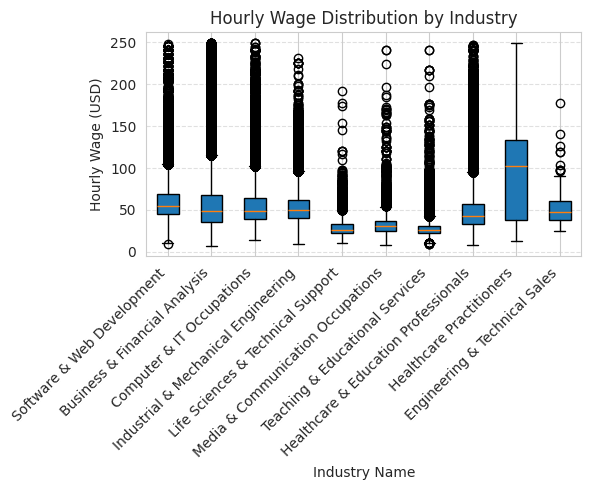

<ipython-input-19-138a47ce3615>:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



<ipython-input-22-e5d52e7bdaef>:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



<ipython-input-25-eac720c5bf50>:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-25-eac720c5bf50>:31: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



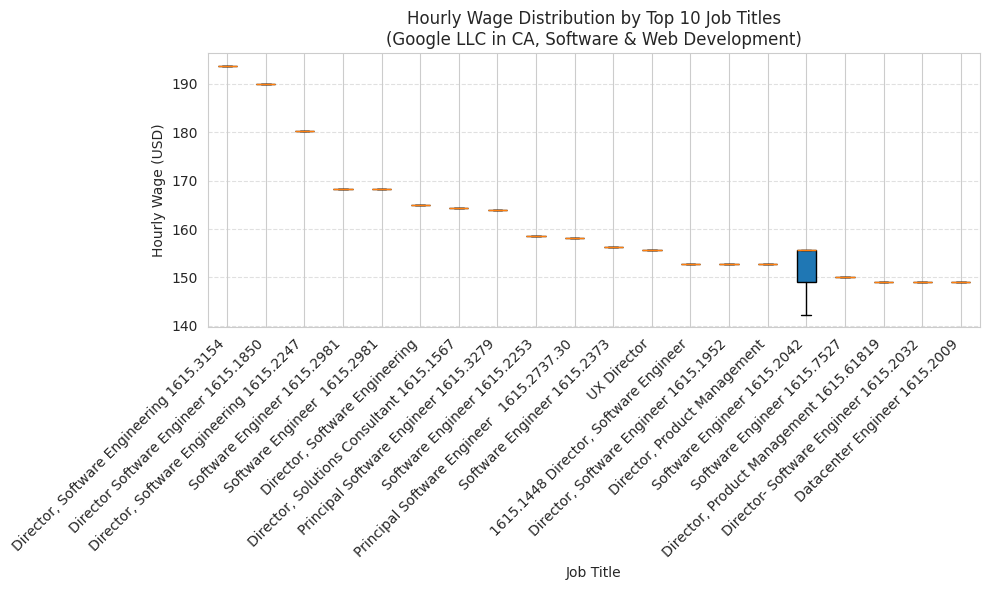

Industry: Software & Web Development
State: CA
Employer: Google LLC
Job Title: Director, Software Engineering 1615.3154


In [ ]:
industry = find_industry(search_space_data)
state = find_state(search_space_data, industry)
employer = find_company(search_space_data, industry, state)
job_title = find_job_title(search_space_data, industry, state, employer)

print(f"Industry: {industry}")
print(f"State: {state}")
print(f"Employer: {employer}")
print(f"Job Title: {job_title}")

## Subjective Choice

In [ ]:
categories = data['Category_Name'].unique()

print("Select the categories you are interested in (enter numbers separated by spaces):")
for i, category in enumerate(categories):
    print(f"{i+1}. {category}")

selected_indices = input("Enter your choices: ").split()
selected_categories = [categories[int(i)-1] for i in selected_indices if 1 <= int(i) <= len(categories)]

filtered_data = data[data['Category_Name'].isin(selected_categories)]



states = filtered_data['EMPLOYER_STATE'].unique()

print("\nSelect the states you are interested in (enter numbers separated by spaces):")
for i, state in enumerate(states):
    print(f"{i+1}. {state}")

selected_state_indices = input("Enter your choices: ").split()
selected_states = [states[int(i) - 1] for i in selected_state_indices if 1 <= int(i) <= len(states)]

search_space_data = filtered_data[filtered_data['EMPLOYER_STATE'].isin(selected_states) & filtered_data['AGENT_ATTORNEY_STATE'].isin(selected_states)]

Select the categories you are interested in (enter numbers separated by spaces):
1. Software & Web Development
2. Business & Financial Analysis
3. Computer & IT Occupations
4. Industrial & Mechanical Engineering
5. Life Sciences & Technical Support
6. Media & Communication Occupations
7. Teaching & Educational Services
8. Healthcare & Education Professionals
9. Healthcare Practitioners
10. Engineering & Technical Sales
Enter your choices: 5 

Select the states you are interested in (enter numbers separated by spaces):
1. CO
2. IL
3. NY
4. MD
5. MI
6. KY
7. PA
8. MA
9. DC
10. OR
11. CA
12. OH
13. AL
14. TX
15. MO
16. NJ
17. GA
18. KS
19. MN
20. NE
21. WA
22. NM
23. NC
24. UT
25. WY
26. FL
27. WI
28. SC
29. TN
30. VA
31. ND
32. LA
33. AK
34. AZ
35. SD
36. IA
37. DE
38. OK
39. CT
40. RI
41. WV
42. NV
43. VT
44. MS
45. ME
46. IN
47. AR
48. NH
49. MP
50. PR
51. ID
52. HI
53. MT
54. GU
55. nan
Enter your choices: 7


<ipython-input-14-fedcdc039c9e>:13: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



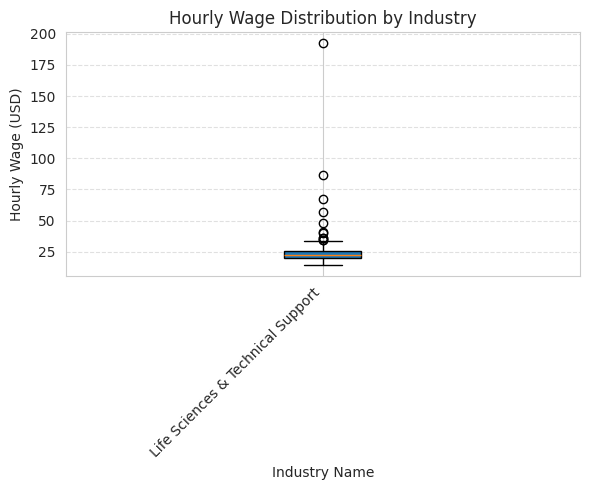

<ipython-input-16-4b465dfecb26>:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



<ipython-input-25-eac720c5bf50>:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-25-eac720c5bf50>:31: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



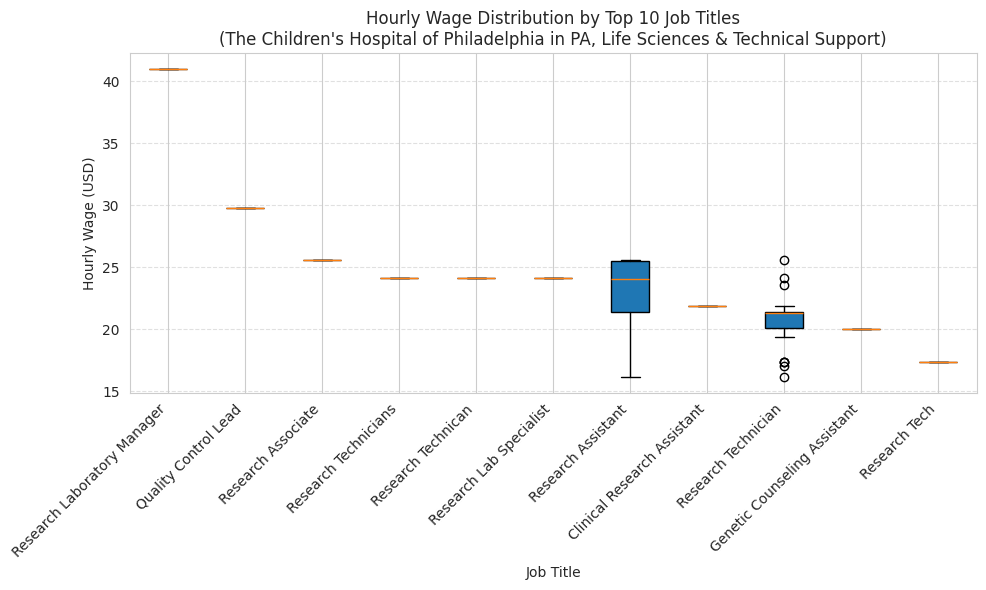

Industry: Life Sciences & Technical Support
State: PA
Employer: The Children's Hospital of Philadelphia
Job Title: Research Laboratory Manager


In [ ]:
industry = find_industry(search_space_data)
state = find_state(search_space_data, industry)
employer = find_company(search_space_data, industry, state)
job_title = find_job_title(search_space_data, industry, state, employer)

print(f"Industry: {industry}")
print(f"State: {state}")
print(f"Employer: {employer}")
print(f"Job Title: {job_title}")